In [1]:
import random
import numpy as np

random.seed(189)
np.random.seed(189)

import matplotlib.pyplot as plt
from scipy import io
import pandas as pd

from scipy.stats import multivariate_normal

In [2]:
# Load data
mnist = np.load("/kaggle/input/uc-berkeley-cs-189-hw-3-mnist-spring-2025/mnist-data.npz") # May have to change file path
mnist_training_data, mnist_training_labels = mnist['training_data'], mnist['training_labels']
mnist_test_data = mnist['test_data']

In [3]:
# Function that shuffles data given a dataset and its labels
def shuffle_data_labels(data, labels):
    data_points = np.arange(data.shape[0])
    np.random.shuffle(data_points)
    return [data[data_points], labels[data_points]]
    
# Shuffle dataset
mnist_training_data, mnist_training_labels = shuffle_data_labels(mnist_training_data, mnist_training_labels)

# Partition the shuffled datasets
mnist_training_set_data, mnist_training_set_labels = mnist_training_data[10000:, :], mnist_training_labels[10000:]
mnist_validation_set_data, mnist_validation_set_labels = mnist_training_data[:10000, :], mnist_training_labels[:10000]

mnist_training_set_data = np.squeeze(mnist_training_set_data, axis=1) # Remove the single dimension 1
mnist_training_set_data = mnist_training_set_data.reshape(mnist_training_set_data.shape[0], -1) # Flatten

mnist_validation_set_data = np.squeeze(mnist_validation_set_data, axis=1) # Remove the single dimension 1
mnist_validation_set_data = mnist_validation_set_data.reshape(mnist_validation_set_data.shape[0], -1) # Flatten

### (1) Taking pixel values as features (no new features yet, please), fit a Gaussian distribution to each digit class using maximum likelihood estimation.  This involves computing a mean and a covariance matrix for each digit class.

**Hint:** You may, and probably should, contrast-normalize the images before using their pixel values. One way to normalize is to divide the pixel values of an image by the $\ell_2$-norm of its pixel values.

In [4]:
def normalize(X):
    centered_X = X - np.mean(X, axis=1, keepdims=True)

    norms = np.linalg.norm(centered_X, axis=1, keepdims=True) + 1e-8

    return centered_X / norms

In [5]:
mnist_training_set_data = normalize(mnist_training_set_data)
mnist_validation_set_data = normalize(mnist_validation_set_data)

In [6]:
digits = range(10)
means = []
covariances = []

for digit in digits:
    training_digit = mnist_training_set_data[mnist_training_set_labels.ravel() == digit]

    means.append(np.mean(training_digit, axis=0))
    covariances.append(np.cov(training_digit, rowvar=False))

### (2) Visualize the covariance matrix for a particular class (digit). Tell us which digit and include your visualization in your write-up. How do the diagonal terms compare with the off-diagonal terms? What do you conclude from this?

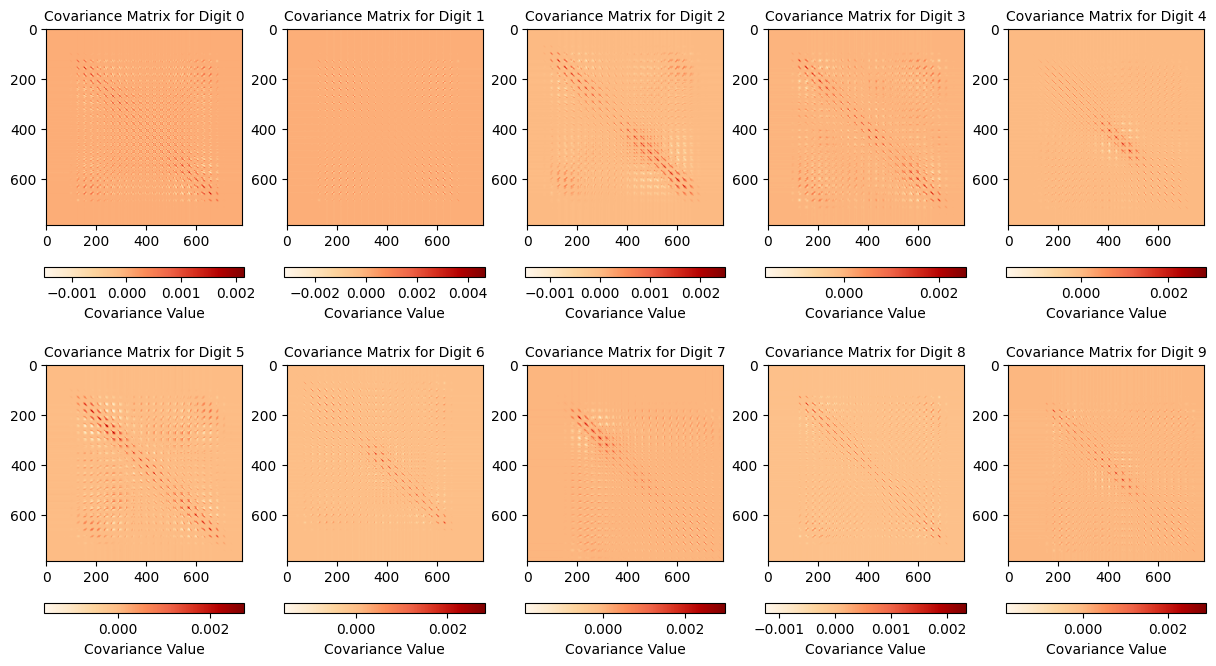

In [7]:
plt.figure(figsize=(15, 8))

for digit in digits:
    plt.subplot(2, 5, digit + 1)
    plt.imshow(covariances[digit], cmap='OrRd')
    plt.title(f"Covariance Matrix for Digit {digit}", fontsize=10)
    plt.colorbar(label='Covariance Value', location='bottom', orientation='horizontal')

### (3) Classify the digits in the test set on the basis of posterior probabilities with two different approaches.

#### (a) LDA

In [8]:
def pooled_within_class_covariance(X, y, means):
    n, d = X.shape
    pooled_cov = np.zeros((d, d))

    for c in range(len(means)):
        class_data = X[y == c]
        class_mean = means[c]
        centered_data = class_data - class_mean
        pooled_cov += np.dot(centered_data.T, centered_data)

    return pooled_cov / n

def lda_log_posterior(X, means, pooled_cov, priors):
    n, d = X.shape
    c = len(means)
    log_post = np.zeros((n, c))

    pooled_cov = pooled_cov + 1e-8 * np.identity(d)

    for i in range(c):
        log_pdf = multivariate_normal.logpdf(X, mean=means[i], cov=pooled_cov)
        
        log_post[:, i] = log_pdf + np.log(priors[i])

    return log_post

def sample_training_data(X, y, size):
    indices = np.random.choice(X.shape[0], size, replace=False)
    return X[indices], y[indices]

In [9]:
training_sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 30000, 50000]
lda_error_rates = []
lda_error_rates_per_digit = {digit: [] for digit in digits}

for size in training_sizes:
    mnist_training_subset_data, mnist_training_subset_labels = sample_training_data(mnist_training_set_data, mnist_training_set_labels.ravel(), size)

    means = []
    for digit in digits:
        class_data = mnist_training_subset_data[mnist_training_subset_labels == digit]
        means.append(np.mean(class_data, axis=0))
    pooled_cov = pooled_within_class_covariance(mnist_training_subset_data, mnist_training_subset_labels, means)
    priors = np.bincount(mnist_training_subset_labels) / len(mnist_training_subset_labels)

    log_post = lda_log_posterior(mnist_validation_set_data, means, pooled_cov, priors)
    digit_pred = np.argmax(log_post, axis=1)
    for digit in digits:
        digit_mask = (mnist_validation_set_labels.ravel() == digit)
        digit_error_rate = 1 - np.mean(digit_pred[digit_mask] == mnist_validation_set_labels.ravel()[digit_mask])
        lda_error_rates_per_digit[digit].append(digit_error_rate)

    error_rate = 1 - np.mean(digit_pred == mnist_validation_set_labels.ravel())
    lda_error_rates.append(error_rate)

    print(f"Training Size: {size}, Validation Error Rate: {error_rate:.4f}")

Training Size: 100, Validation Error Rate: 0.3118
Training Size: 200, Validation Error Rate: 0.3104
Training Size: 500, Validation Error Rate: 0.6715
Training Size: 1000, Validation Error Rate: 0.3182
Training Size: 2000, Validation Error Rate: 0.1839
Training Size: 5000, Validation Error Rate: 0.1419
Training Size: 10000, Validation Error Rate: 0.1329
Training Size: 30000, Validation Error Rate: 0.1225
Training Size: 50000, Validation Error Rate: 0.1236


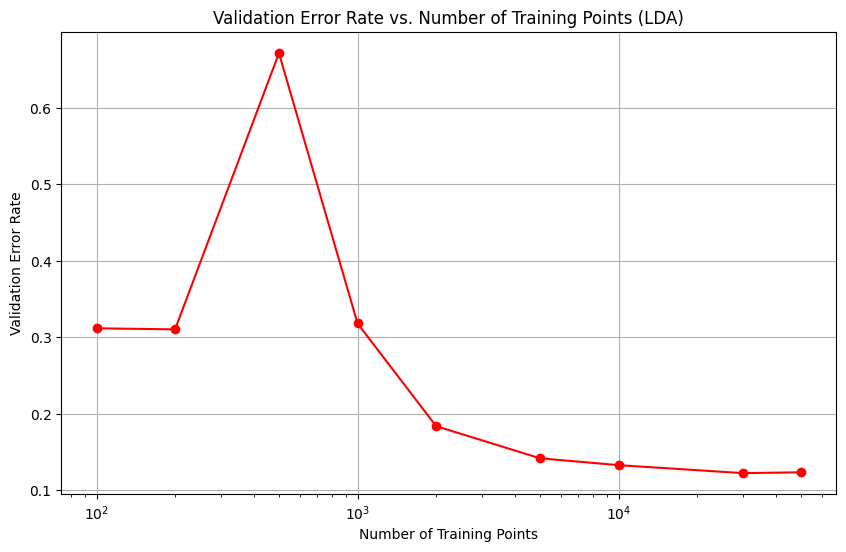

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(training_sizes, lda_error_rates, marker='o', linestyle='-', color='r')
plt.xscale('log')
plt.xlabel('Number of Training Points')
plt.ylabel('Validation Error Rate')
plt.title('Validation Error Rate vs. Number of Training Points (LDA)')
plt.grid(True)
plt.show()

#### (b) QDA

In [12]:
def conditional_covariance(X, y, means):
    covariances = []

    for c in range(len(means)):
        class_data = X[y == c]
        class_mean = means[c]
        centered_data = class_data - class_mean

        cov = np.dot(centered_data.T, centered_data) / len(class_data)

        covariances.append(cov)

    return covariances

def qda_log_posterior(X, means, covariances, priors):
    n, d = X.shape
    c = len(means)
    log_post = np.zeros((n, c))

    for i in range(c):
        cov = covariances[i] + 1e-8 * np.identity(d)

        log_pdf = multivariate_normal.logpdf(X, mean=means[i], cov=cov)

        log_post[:, i] = log_pdf + np.log(priors[i])

    return log_post

In [13]:
training_sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 30000, 50000]
qda_error_rates = []
qda_error_rates_per_digit = {digit: [] for digit in digits}

for size in training_sizes:
    mnist_training_subset_data, mnist_training_subset_labels = sample_training_data(mnist_training_set_data, mnist_training_set_labels.ravel(), size)

    means = []
    for digit in digits:
        class_data = mnist_training_subset_data[mnist_training_subset_labels == digit]
        means.append(np.mean(class_data, axis=0))
    covariances = conditional_covariance(mnist_training_subset_data, mnist_training_subset_labels, means)
    priors = np.bincount(mnist_training_subset_labels) / len(mnist_training_subset_labels)

    log_post = qda_log_posterior(mnist_validation_set_data, means, covariances, priors)
    digit_pred = np.argmax(log_post, axis=1)
    for digit in digits:
        digit_mask = (mnist_validation_set_labels == digit)
        digit_error_rate = 1 - np.mean(digit_pred[digit_mask] == mnist_validation_set_labels.ravel()[digit_mask])
        qda_error_rates_per_digit[digit].append(digit_error_rate)

    error_rate = 1 - np.mean(digit_pred == mnist_validation_set_labels.ravel())
    qda_error_rates.append(error_rate)

    print(f"Training Size: {size}, Validation Error Rate: {error_rate:.4f}")

Training Size: 100, Validation Error Rate: 0.2637
Training Size: 200, Validation Error Rate: 0.1771
Training Size: 500, Validation Error Rate: 0.0990
Training Size: 1000, Validation Error Rate: 0.0925
Training Size: 2000, Validation Error Rate: 0.1700
Training Size: 5000, Validation Error Rate: 0.3194
Training Size: 10000, Validation Error Rate: 0.1820
Training Size: 30000, Validation Error Rate: 0.1802
Training Size: 50000, Validation Error Rate: 0.1994


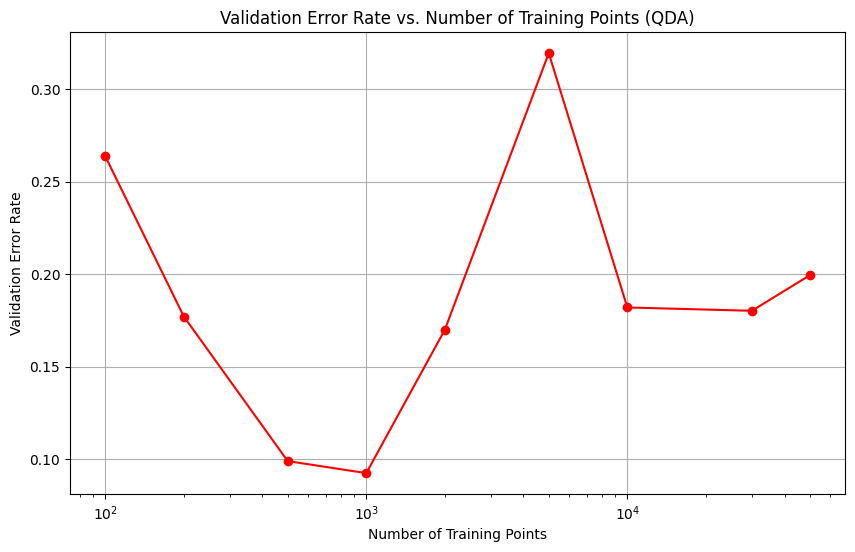

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(training_sizes, qda_error_rates, marker='o', linestyle='-', color='r')
plt.xscale('log')
plt.xlabel('Number of Training Points')
plt.ylabel('Validation Error Rate')
plt.title('Validation Error Rate vs. Number of Training Points (QDA)')
plt.grid(True)
plt.show()

#### (d) Include two plots, one using LDA and one using QDA, of validation error versus the number of training points for each digit. Each plot should include all the 10 curves on the same graph. Which digit is easiest to classify for LDA/QDA?

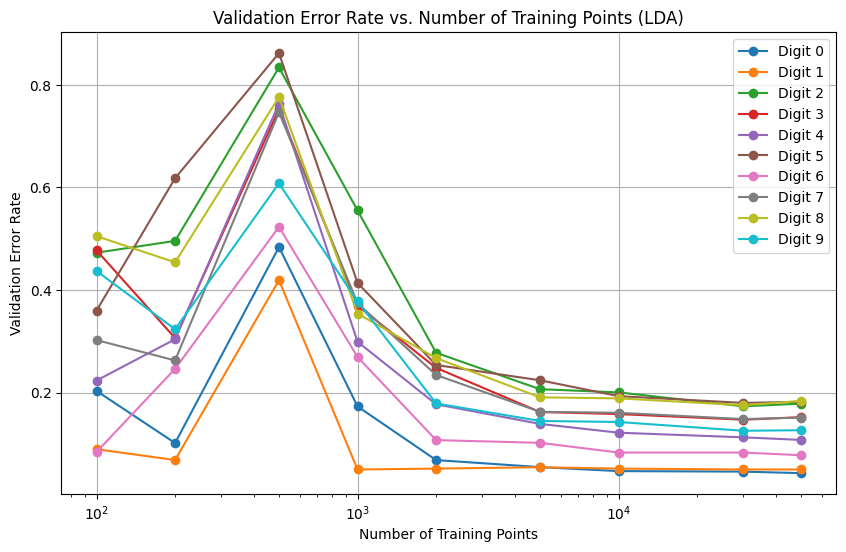

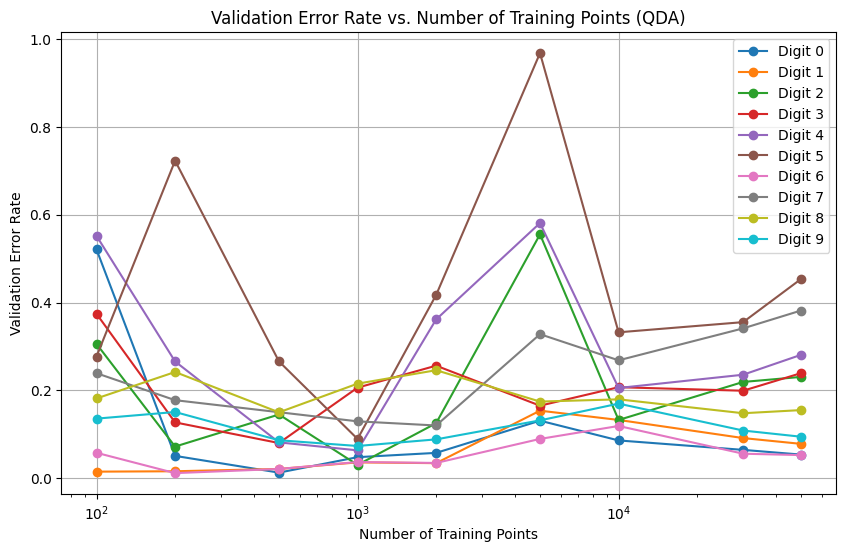

In [15]:
# LDA
plt.figure(figsize=(10, 6))
for digit in digits:
    plt.plot(training_sizes, lda_error_rates_per_digit[digit], marker='o', label=f'Digit {digit}')
plt.xscale('log')
plt.xlabel('Number of Training Points')
plt.ylabel('Validation Error Rate')
plt.title('Validation Error Rate vs. Number of Training Points (LDA)')
plt.legend()
plt.grid(True)
plt.show()

# QDA
plt.figure(figsize=(10, 6))
for digit in digits:
    plt.plot(training_sizes, qda_error_rates_per_digit[digit], marker='o', label=f'Digit {digit}')
plt.xscale('log')
plt.xlabel('Number of Training Points')
plt.ylabel('Validation Error Rate')
plt.title('Validation Error Rate vs. Number of Training Points (QDA)')
plt.legend()
plt.grid(True)
plt.show()

### (4) With `mnist-data-hw3.npz`, train your best classifier for the `training_data` and classify the images in the `test_data`.

In [16]:
# Generate CSV file
def results_to_csv(y_test, file_name):
    y_test = y_test.astype(int)
    df = pd.DataFrame({'Category': y_test})
    df.index += 1
    df.to_csv(file_name, index_label='Id')

In [18]:
mnist_training_data_squeeze = np.squeeze(mnist_training_data, axis=1) # Remove the single dimension 1
mnist_training_set_data_flattened = mnist_training_data_squeeze.reshape(mnist_training_data_squeeze.shape[0], -1) # Flatten
mnist_training_set_data_normalized = normalize(mnist_training_set_data_flattened)

mnist_test_data_squeeze = np.squeeze(mnist_test_data, axis=1)
mnist_test_data_flattened = mnist_test_data_squeeze.reshape(mnist_test_data_squeeze.shape[0], -1)
mnist_test_data_normalized = normalize(mnist_test_data_flattened)

In [19]:
means = []
for digit in digits:
    class_data = mnist_training_set_data_normalized[mnist_training_labels == digit]
    means.append(np.mean(class_data, axis=0))
pooled_cov = pooled_within_class_covariance(mnist_training_set_data_normalized, mnist_training_labels, means)
priors = np.bincount(mnist_training_labels) / len(mnist_training_labels)

log_post = lda_log_posterior(mnist_test_data_normalized, means, pooled_cov, priors)
y_test = np.argmax(log_post, axis=1)

In [20]:
results_to_csv(y_test, 'mnist-submission.csv')
print("Submission file 'mnist-submission.csv' has been created.")

Submission file 'mnist-submission.csv' has been created.
